In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima
from arch import arch_model

from sklearn.metrics import mean_squared_error, mean_absolute_error
import datetime

In [2]:
np.random.seed(42)

In [3]:
# Parameters
TICKER = '^NSEI'  # Yahoo ticker for NIFTY 50
START = '2014-01-01'
END = '2016-12-31'
OUT_DIR = os.path.join('..', 'data')
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: ..\data


In [4]:
df = yf.download(TICKER, start=START, end=END, progress=False)
if df.empty:
    raise RuntimeError('Data download returned empty DataFrame. Confirm ticker and network access.')
csv_path = os.path.join(OUT_DIR, 'nifty_2014_2016.csv')
df.to_csv(csv_path)
print('Saved:', csv_path)
df.head()

C:\Users\mouli\AppData\Local\Temp\ipykernel_23060\3628642607.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START, end=END, progress=False)


Saved: ..\data\nifty_2014_2016.csv


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


In [5]:
df.reset_index(inplace=True)
df.columns = df.columns.droplevel(1)

In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.drop_duplicates(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [7]:
df = df[['Date', 'Close']]

In [8]:
df = df.set_index('Date').sort_index()

In [9]:
df

Price,Close
Date,
2014-01-02,6221.149902
2014-01-03,6211.149902
2014-01-06,6191.450195
2014-01-07,6162.250000
2014-01-08,6174.600098
...,...
2016-12-26,7908.250000
2016-12-27,8032.850098
2016-12-28,8034.850098


In [10]:
print("\nData range:", df.index.min(), "to", df.index.max())
print("Number of rows:", len(df))


Data range: 2014-01-02 00:00:00 to 2016-12-30 00:00:00
Number of rows: 728


In [11]:
df['LogPrice'] = np.log(df['Close'])
df['LogReturn'] = df['LogPrice'].diff()
df = df.dropna(subset=['LogReturn'])

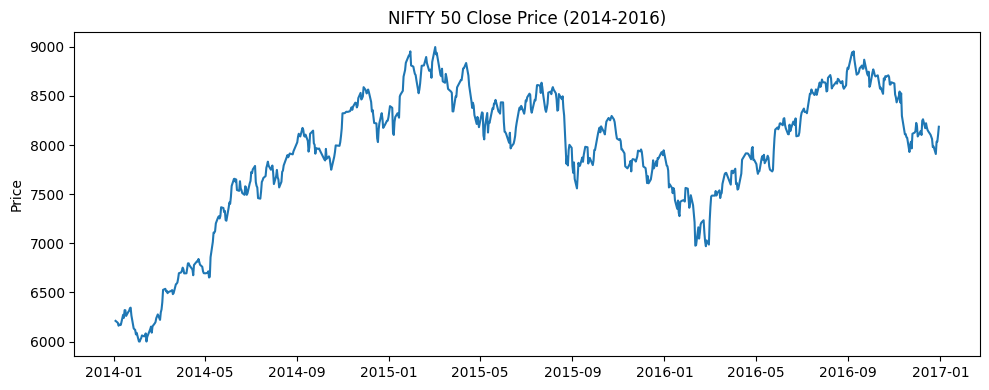

In [12]:
plt.figure(figsize=(10,4))
plt.plot(df['Close'])
plt.title("NIFTY 50 Close Price (2014-2016)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


The plot shows the daily closing prices of the NIFTY 50 index from 2014 to 2016. The index exhibits significant fluctuations over the three-year period, reflecting the typical movement of a broad equity market. The series shows an overall upward trend during 2014 and early 2015, followed by a noticeable decline in late 2015 and early 2016. After mid-2016, the index recovers again and reaches new highs before declining slightly toward the end of 2016. This behavior indicates the presence of market cycles, volatility, and non-stationarity in price levels, which is why returns (rather than prices) are typically used for time-series modelling.

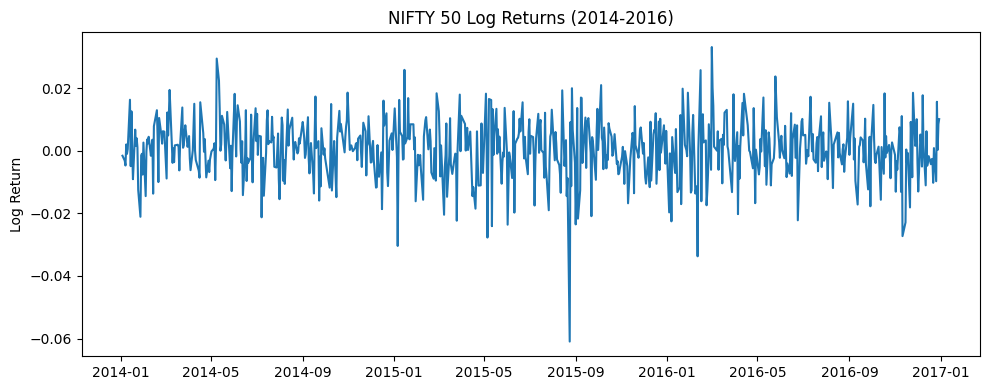

In [13]:
plt.figure(figsize=(10,4))
plt.plot(df['LogReturn'])
plt.title("NIFTY 50 Log Returns (2014-2016)")
plt.ylabel("Log Return")
plt.tight_layout()
plt.show()

The log-return series fluctuates around a mean close to zero, which is typical for financial return data. Unlike the price series, the returns do not display any clear long-term trend, confirming their stationarity. The plot also reveals occasional large spikes, which correspond to periods of heightened market volatility. Such volatility clustering, periods of high volatility followed by more high volatility is a common feature in financial time series and justifies the use of ARCH/GARCH-type models later in the analysis.

In [14]:
adf_res = adfuller(df['LogReturn'], autolag='AIC')
print("\nADF test statistic: {:.6f}".format(adf_res[0]))
print("ADF p-value: {:.6e}".format(adf_res[1]))
print("Used lags:", adf_res[2])
print("Number of observations:", adf_res[3])
print("Critical values:")
for k, v in adf_res[4].items():
    print(f"  {k}: {v:.6f}")



ADF test statistic: -14.660295
ADF p-value: 3.389873e-27
Used lags: 2
Number of observations: 724
Critical values:
  1%: -3.439414
  5%: -2.865540
  10%: -2.568900


The ADF test strongly rejects the null hypothesis of a unit root (ADF statistic = –14.66 < –3.43 at 1% level, p-value ≈ 0). This confirms that the NIFTY 50 log-return series is stationary and suitable for ARIMA modeling.
ADF automatically selected 3 lags based on information criteria to remove autocorrelation in residuals.

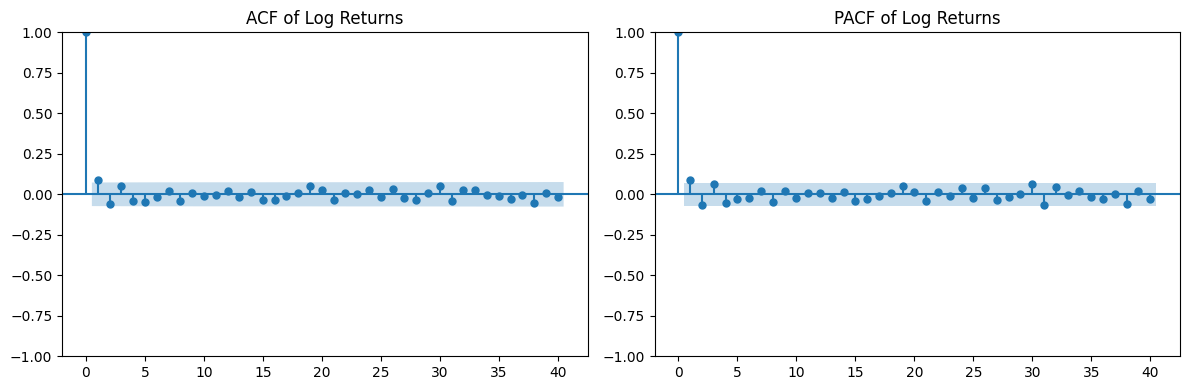

In [15]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_acf(df['LogReturn'], lags=40, ax=plt.gca(), title="ACF of Log Returns")
plt.subplot(1,2,2)
plot_pacf(df['LogReturn'], lags=40, ax=plt.gca(), method='ywm', title="PACF of Log Returns")
plt.tight_layout()
plt.show()

The ACF and PACF plots of the log returns show that almost all autocorrelations lie within the confidence bounds, except at lag 1. This indicates that the return series has very weak linear dependence, which is consistent with the efficient market hypothesis. The only spike at lag 1 suggests that a simple ARIMA(1,0,1) or ARMA(1,1) model is appropriate for capturing any remaining short-term dynamics in the return process. Overall, the plots confirm that the returns are largely uncorrelated but may still exhibit heteroskedastic behavior.

In [16]:
# Train / test split (hold-out last h business days)
h = 60   
train = df['LogReturn'].iloc[:-h].copy()
test  = df['LogReturn'].iloc[-h:].copy()

print("\nTrain length:", len(train), "Test length:", len(test))



Train length: 667 Test length: 60


In [17]:
# ARIMA order selection on train (auto_arima)
print("\nRunning auto_arima (this may take a moment)...")
arima_auto = auto_arima(train, start_p=0, start_q=0, max_p=5, max_q=5,
                        seasonal=False, stepwise=True, suppress_warnings=True,
                        information_criterion='aic', trace=False)
order = arima_auto.order
print("Selected ARIMA order:", order)


Running auto_arima (this may take a moment)...
Selected ARIMA order: (1, 0, 1)


In [18]:
sarimax_mod = sm.tsa.SARIMAX(train, order=order, enforce_stationarity=False, enforce_invertibility=False)
sarimax_res = sarimax_mod.fit(disp=False)
print("\nARIMA (SARIMAX) summary:")
print(sarimax_res.summary())


ARIMA (SARIMAX) summary:
                               SARIMAX Results                                
Dep. Variable:              LogReturn   No. Observations:                  667
Model:               SARIMAX(1, 0, 1)   Log Likelihood                2166.255
Date:                Sun, 16 Nov 2025   AIC                          -4326.510
Time:                        20:26:27   BIC                          -4313.010
Sample:                             0   HQIC                         -4321.279
                                - 667                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6433      0.113     -5.689      0.000      -0.865      -0.422
ma.L1          0.7649      0.094      8.129      0.000       0.580       0.949
sigma2      8.652e-05   2.

d:\Sem 5\Time Series\predicting-nifty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Sem 5\Time Series\predicting-nifty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


The **ARIMA (1,0,1) model fits the log-return series** reasonably well. Both the AR(1) and MA(1) coefficients are statistically significant (p-values < 0.05), indicating **short-term dependence in the returns**. The residual variance (sigma²) is small, reflecting the low average volatility of daily returns. However, the model diagnostics show non-normal residuals (significant Jarque–Bera test) and high kurtosis, which are common characteristics of financial returns. These observations suggest that, although the ARIMA model captures the mean dynamics effectively, it does not fully account for volatility clustering **motivating the use of a GARCH model**.

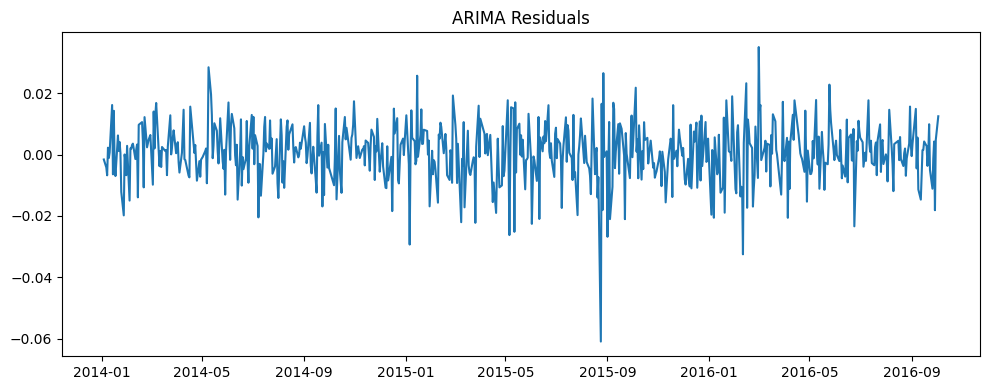

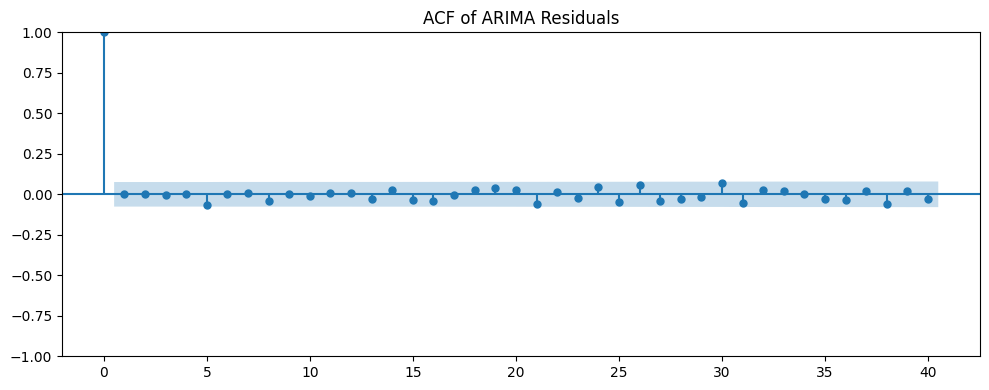

In [19]:
# 8) Residual diagnostics (ARIMA residuals)
resid = sarimax_res.resid.dropna()
plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title("ARIMA Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plot_acf(resid, lags=40, ax=plt.gca(), title="ACF of ARIMA Residuals")
plt.tight_layout()
plt.show()

The residual plot appears to fluctuate randomly around zero without any visible pattern, which indicates that the ARIMA model has successfully captured the linear structure in the return series. Additionally, the ACF of residuals shows no significant autocorrelation at any lag, confirming that the residuals behave like white noise. This is further supported by the Ljung–Box test result, which fails to reject the null hypothesis of no autocorrelation. Therefore, the ARIMA model is adequate for modeling the conditional mean of the return series.

In [20]:
# Ljung-Box on residuals
lb_res = acorr_ljungbox(resid, lags=[10], return_df=True)
print("\nLjung-Box test for residuals (lag 10):")
print(lb_res)



Ljung-Box test for residuals (lag 10):
     lb_stat  lb_pvalue
10  4.397468   0.927641


The Ljung–Box test has a very high p-value (≈ 0.92), which means we fail to reject the null hypothesis that residuals are uncorrelated. This confirms that the ARIMA model has successfully removed serial correlation from the return series. In other words, the mean dynamics are well modeled, and no significant autocorrelation remains. However, this test does not assess volatility patterns, only autocorrelation.

In [21]:
# ARCH test on residuals (to justify GARCH)
arch_test_stat, arch_pvalue, _, _ = het_arch(resid, nlags=10)
print("\nARCH test (on residuals) p-value:", arch_pvalue)


ARCH test (on residuals) p-value: 0.0012176134231532655


The ARCH test produces a very small p-value (≈ 0.00121), indicating strong evidence of ARCH effects in the residuals. This means the variance of the residuals is not constant over time and exhibits volatility clustering. As a result, a GARCH model is justified to capture the time-varying volatility in the return series. This aligns with the stylized facts of financial markets, where periods of high volatility tend to cluster together.

In [22]:
train = df[:'2016-07-31'].copy()
test  = df['2016-08-01':].copy()

In [23]:
stepwise = True
print("Selecting ARIMA order on log-price")
model_auto = auto_arima(train['LogPrice'], seasonal=False, stepwise=stepwise,
                        max_p=4, max_q=4, d=None, trace=False, error_action='ignore', suppress_warnings=True)
order = model_auto.order
print("Selected order (p,d,q):", order)

Selecting ARIMA order on log-price
Selected order (p,d,q): (1, 1, 1)


In [24]:
import warnings

warnings.filterwarnings('ignore')
history = train['LogPrice'].copy()
pred_logprice = []
for idx, row in test.iterrows():
    mod = sm.tsa.SARIMAX(history, order=order, enforce_stationarity=False, enforce_invertibility=False)
    res = mod.fit(disp=False)
    # one-step forecast (log-price)
    f = res.get_forecast(steps=1)
    pred = f.predicted_mean.iloc[0]
    pred_logprice.append(pred)
    history = pd.concat([history, pd.Series([row['LogPrice']], index=[idx])])


test = test.copy()
test['pred_logprice'] = pred_logprice
test['pred_price'] = np.exp(test['pred_logprice'])
test['true_price'] = np.exp(test['LogPrice'])

rmse_price = np.sqrt(mean_squared_error(test['true_price'], test['pred_price']))
mae_price  = mean_absolute_error(test['true_price'], test['pred_price'])
print(f"RMSE (price): {rmse_price:.2f}, MAE (price): {mae_price:.2f}")

RMSE (price): 72.30, MAE (price): 54.05


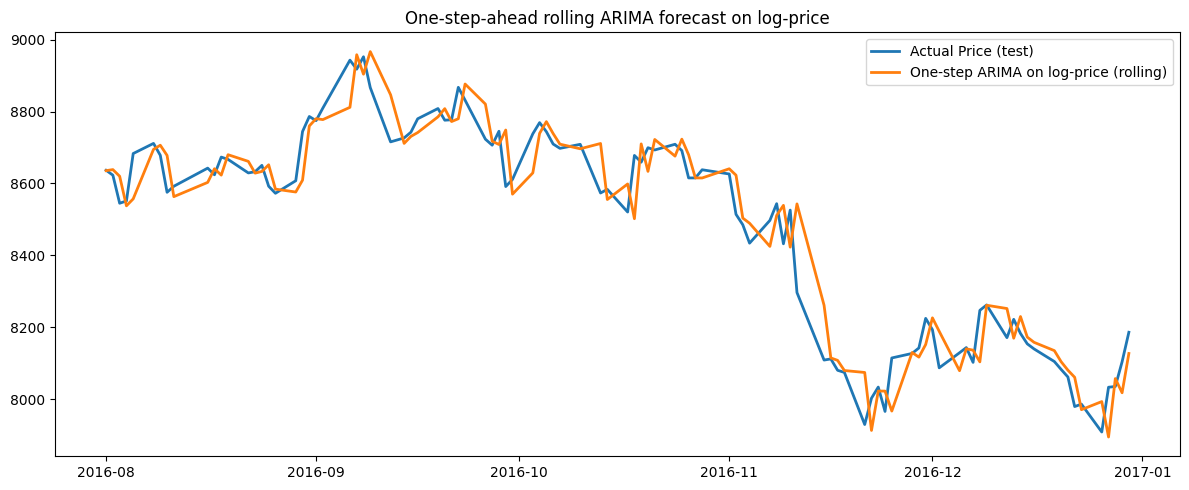

In [25]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test['true_price'], label='Actual Price (test)', linewidth=2)
plt.plot(test.index, test['pred_price'], label='One-step ARIMA on log-price (rolling)', linewidth=2)
plt.legend()
plt.title('One-step-ahead rolling ARIMA forecast on log-price')
plt.tight_layout()
plt.show()
